In [41]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import zipfile
import librosa
import torch
import numpy as np
from SMT import *
from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from tqdm import tqdm

# 1. Update directory and zip names
AUDIO_DIR = Path("./data/LibriSpeech/dev-clean/84/121123")

def list_audio_files(audio_dir: Path):
    # Common audio extensions
    exts = (".wav", ".mp3", ".ogg", ".flac")
    return [p for p in sorted(audio_dir.iterdir()) if p.is_file() and p.suffix.lower() in exts]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
audio_files = list_audio_files(AUDIO_DIR)

In [3]:

out = extract_features_from_files(audio_files[1:15])


mels = [clip["mel_spectrogram"] for _, clip in out.items()]
mfccs = [clip["mfcc"] for _, clip in out.items()]
log_mels = [clip["log_mel_db"] for _, clip in out.items()]

hop_length = [clip["hop_length"] for _, clip in out.items()][0]
sr = [clip["sr"] for _, clip in out.items()][0]

print([a.shape for a in mels])


/Users/zacariabalkhy/UCDAVIS_COURSES/EEC289A/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[(40, 400), (40, 1370), (40, 681), (40, 441), (40, 1597), (40, 563), (40, 201), (40, 702), (40, 270), (40, 720), (40, 326), (40, 257), (40, 241), (40, 289)]


[Text(0.5, 1.0, 'MFCC')]

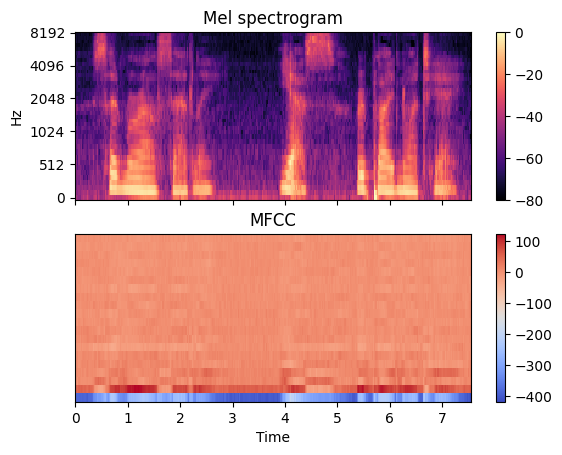

In [4]:
import matplotlib.pyplot as plt

idx = 10
fig, ax = plt.subplots(nrows=2, sharex=True)
img = librosa.display.specshow(log_mels[idx],x_axis='time', y_axis='mel', fmax=8000,ax=ax[0])
fig.colorbar(img, ax=[ax[0]])
ax[0].set(title='Mel spectrogram')
ax[0].label_outer()
img = librosa.display.specshow(mfccs[idx], x_axis='time', ax=ax[1])
fig.colorbar(img, ax=[ax[1]])
ax[1].set(title='MFCC')

In [226]:
print(sr)
print(hop_length)

16000
160


In [53]:
patches = []
utterance_bounds = []
start = 0
for mel in mels:
    p = extract_time_patches(
        features=mel,
        sr=sr,
        hop_length=hop_length,
        patch_ms=300.0,
        patch_hop_frames=1,
    )
    end = start + p.shape[0]
    patches.append(p)
    utterance_bounds.append((start, end))
    start = end
patches = np.concat(patches)

In [54]:
len(utterance_bounds)

14

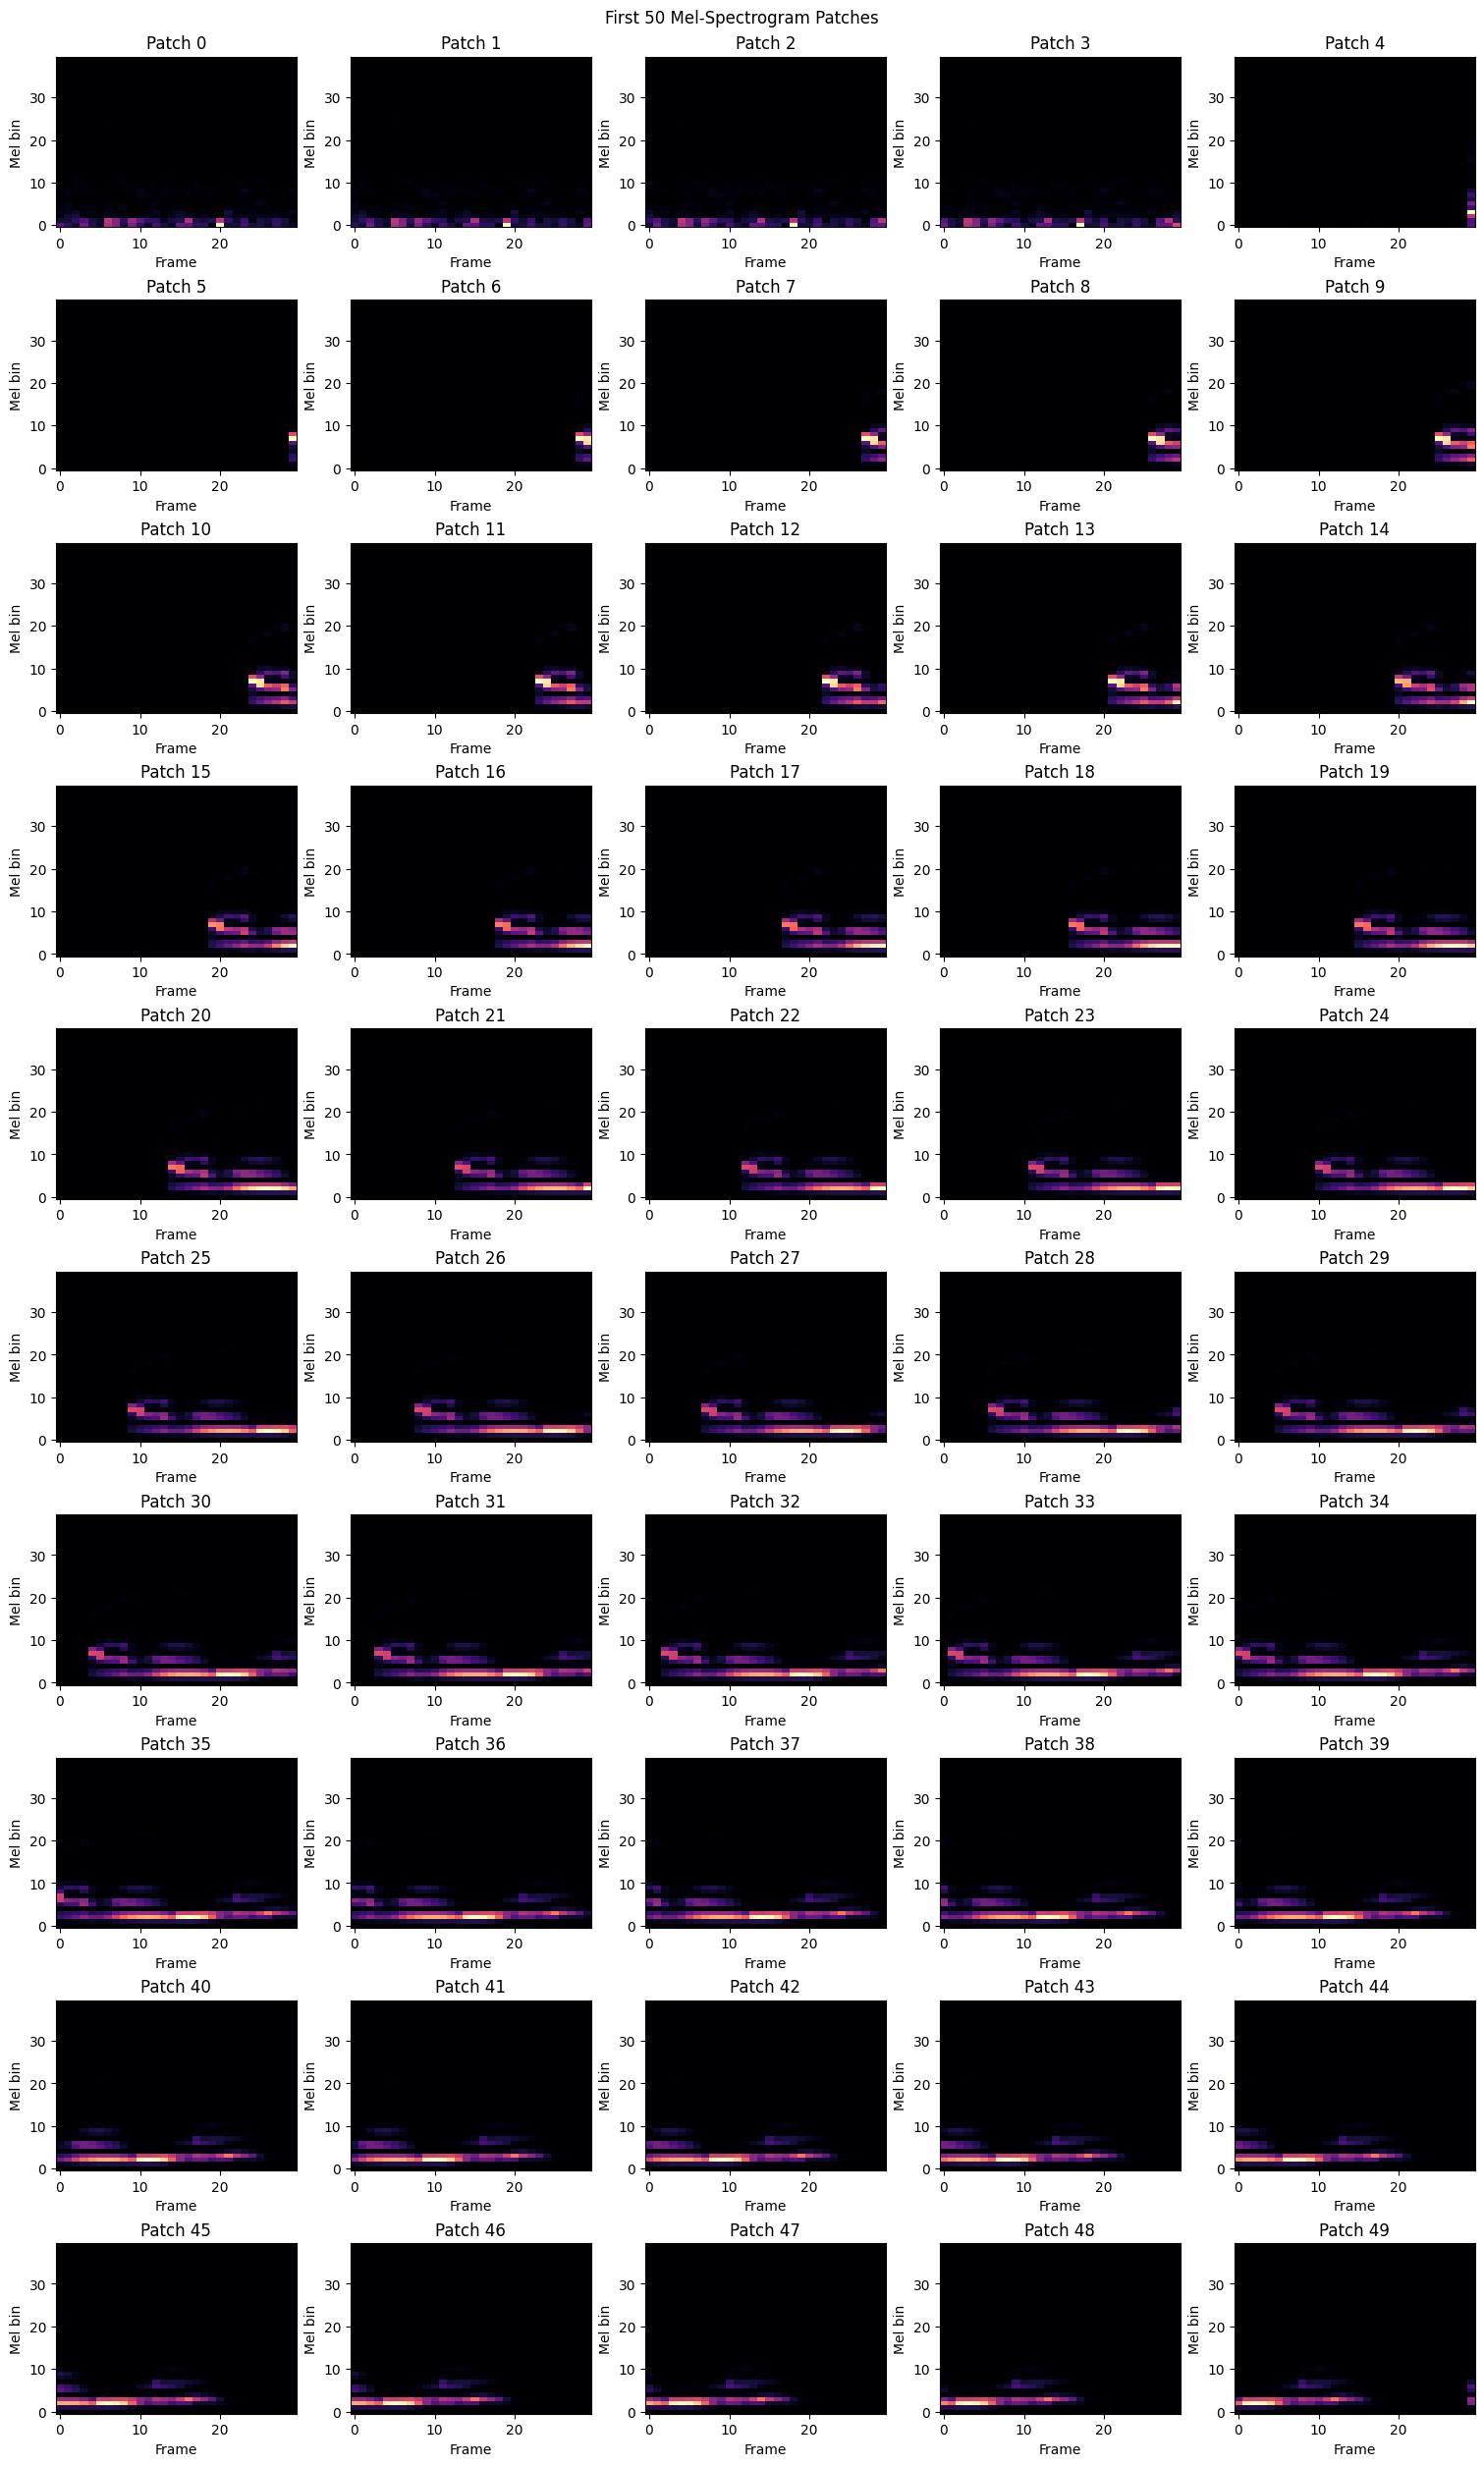

In [7]:
def plot_first_10_mel_patches(mel_patches, n_show=10, cols=5, cmap='magma'):
    """Plot the first n_show mel patches in a single figure grid."""
    import numpy as np
    import matplotlib.pyplot as plt

    mel_patches = np.asarray(mel_patches)
    if mel_patches.ndim != 3:
        raise ValueError('mel_patches must have shape [n_patches, n_mels, n_frames].')

    n_show = min(n_show, mel_patches.shape[0])
    if n_show == 0:
        raise ValueError('mel_patches is empty.')

    rows = int(np.ceil(n_show / cols))
    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(3 * cols, 2.5 * rows),
        squeeze=False,
        constrained_layout=True,
    )
    axes_flat = axes.ravel()

    for i in range(n_show):
        ax = axes_flat[i]
        im = ax.imshow(mel_patches[i], origin='lower', aspect='auto', cmap=cmap)
        ax.set_title(f'Patch {i}')
        ax.set_xlabel('Frame')
        ax.set_ylabel('Mel bin')

    for j in range(n_show, len(axes_flat)):
        axes_flat[j].axis('off')

    # fig.colorbar(im, ax=axes, location='right', fraction=0.03, pad=0.02, label='Power')
    fig.suptitle(f'First {n_show} Mel-Spectrogram Patches')
    plt.show()


plot_first_10_mel_patches(patches.reshape(patches.shape[0], 40, 30), n_show=50, cols=5)

In [8]:
def zca_whitening_matrix(X):
    """
    Function to compute ZCA whitening matrix (aka Mahalanobis whitening).
    INPUT:  X: [M x N] matrix.
        Rows: Variables
        Columns: Observations
    OUTPUT: ZCAMatrix: [M x M] matrix
    """
    # Covariance matrix [column-wise variables]: Sigma = (X-mu)' * (X-mu) / N
    sigma = np.cov(X, rowvar=True) # [M x M]
    # Singular Value Decomposition. X = U * np.diag(S) * V
    U,S,V = np.linalg.svd(sigma)
        # U: [M x M] eigenvectors of sigma.
        # S: [M x 1] eigenvalues of sigma.
        # V: [M x M] transpose of U
    # Whitening constant: prevents division by zero
    epsilon = 1e-5
    # ZCA Whitening matrix: U * Lambda * U'
    ZCAMatrix = np.dot(U, np.dot(np.diag(1.0/np.sqrt(S + epsilon)), U.T)) # [M x M]
    return ZCAMatrix

def preprocess_patches(patches: np.ndarray):
    
    # flatten patches to (N,40*30)
    patch_vectors = patches.reshape(patches.shape[0], -1)
    print(patch_vectors.shape)
    # subtract mean from patches
    mean = np.mean(patch_vectors, axis=1)
    std = np.std(patch_vectors, axis=1)
    patch_vectors = ((patch_vectors.T - mean)/(std + 1e-6)).T
    
    # whiten patches
    #pca = PCA(whiten=True)
    #patch_vectors = pca.fit_transform(patch_vectors)   
    zcaMatrix = zca_whitening_matrix(patch_vectors.T)
    patch_vectors = np.dot(zcaMatrix, patch_vectors.T) # project X onto the ZCAMatrix
    patch_vectors = patch_vectors.T

    # normalize patches
    patch_vectors = normalize(patch_vectors, norm='l2')
    
    return patch_vectors, mean, zcaMatrix

In [9]:
norm_patches, mean, zcaMatrix = preprocess_patches(patches)

(7652, 1200)


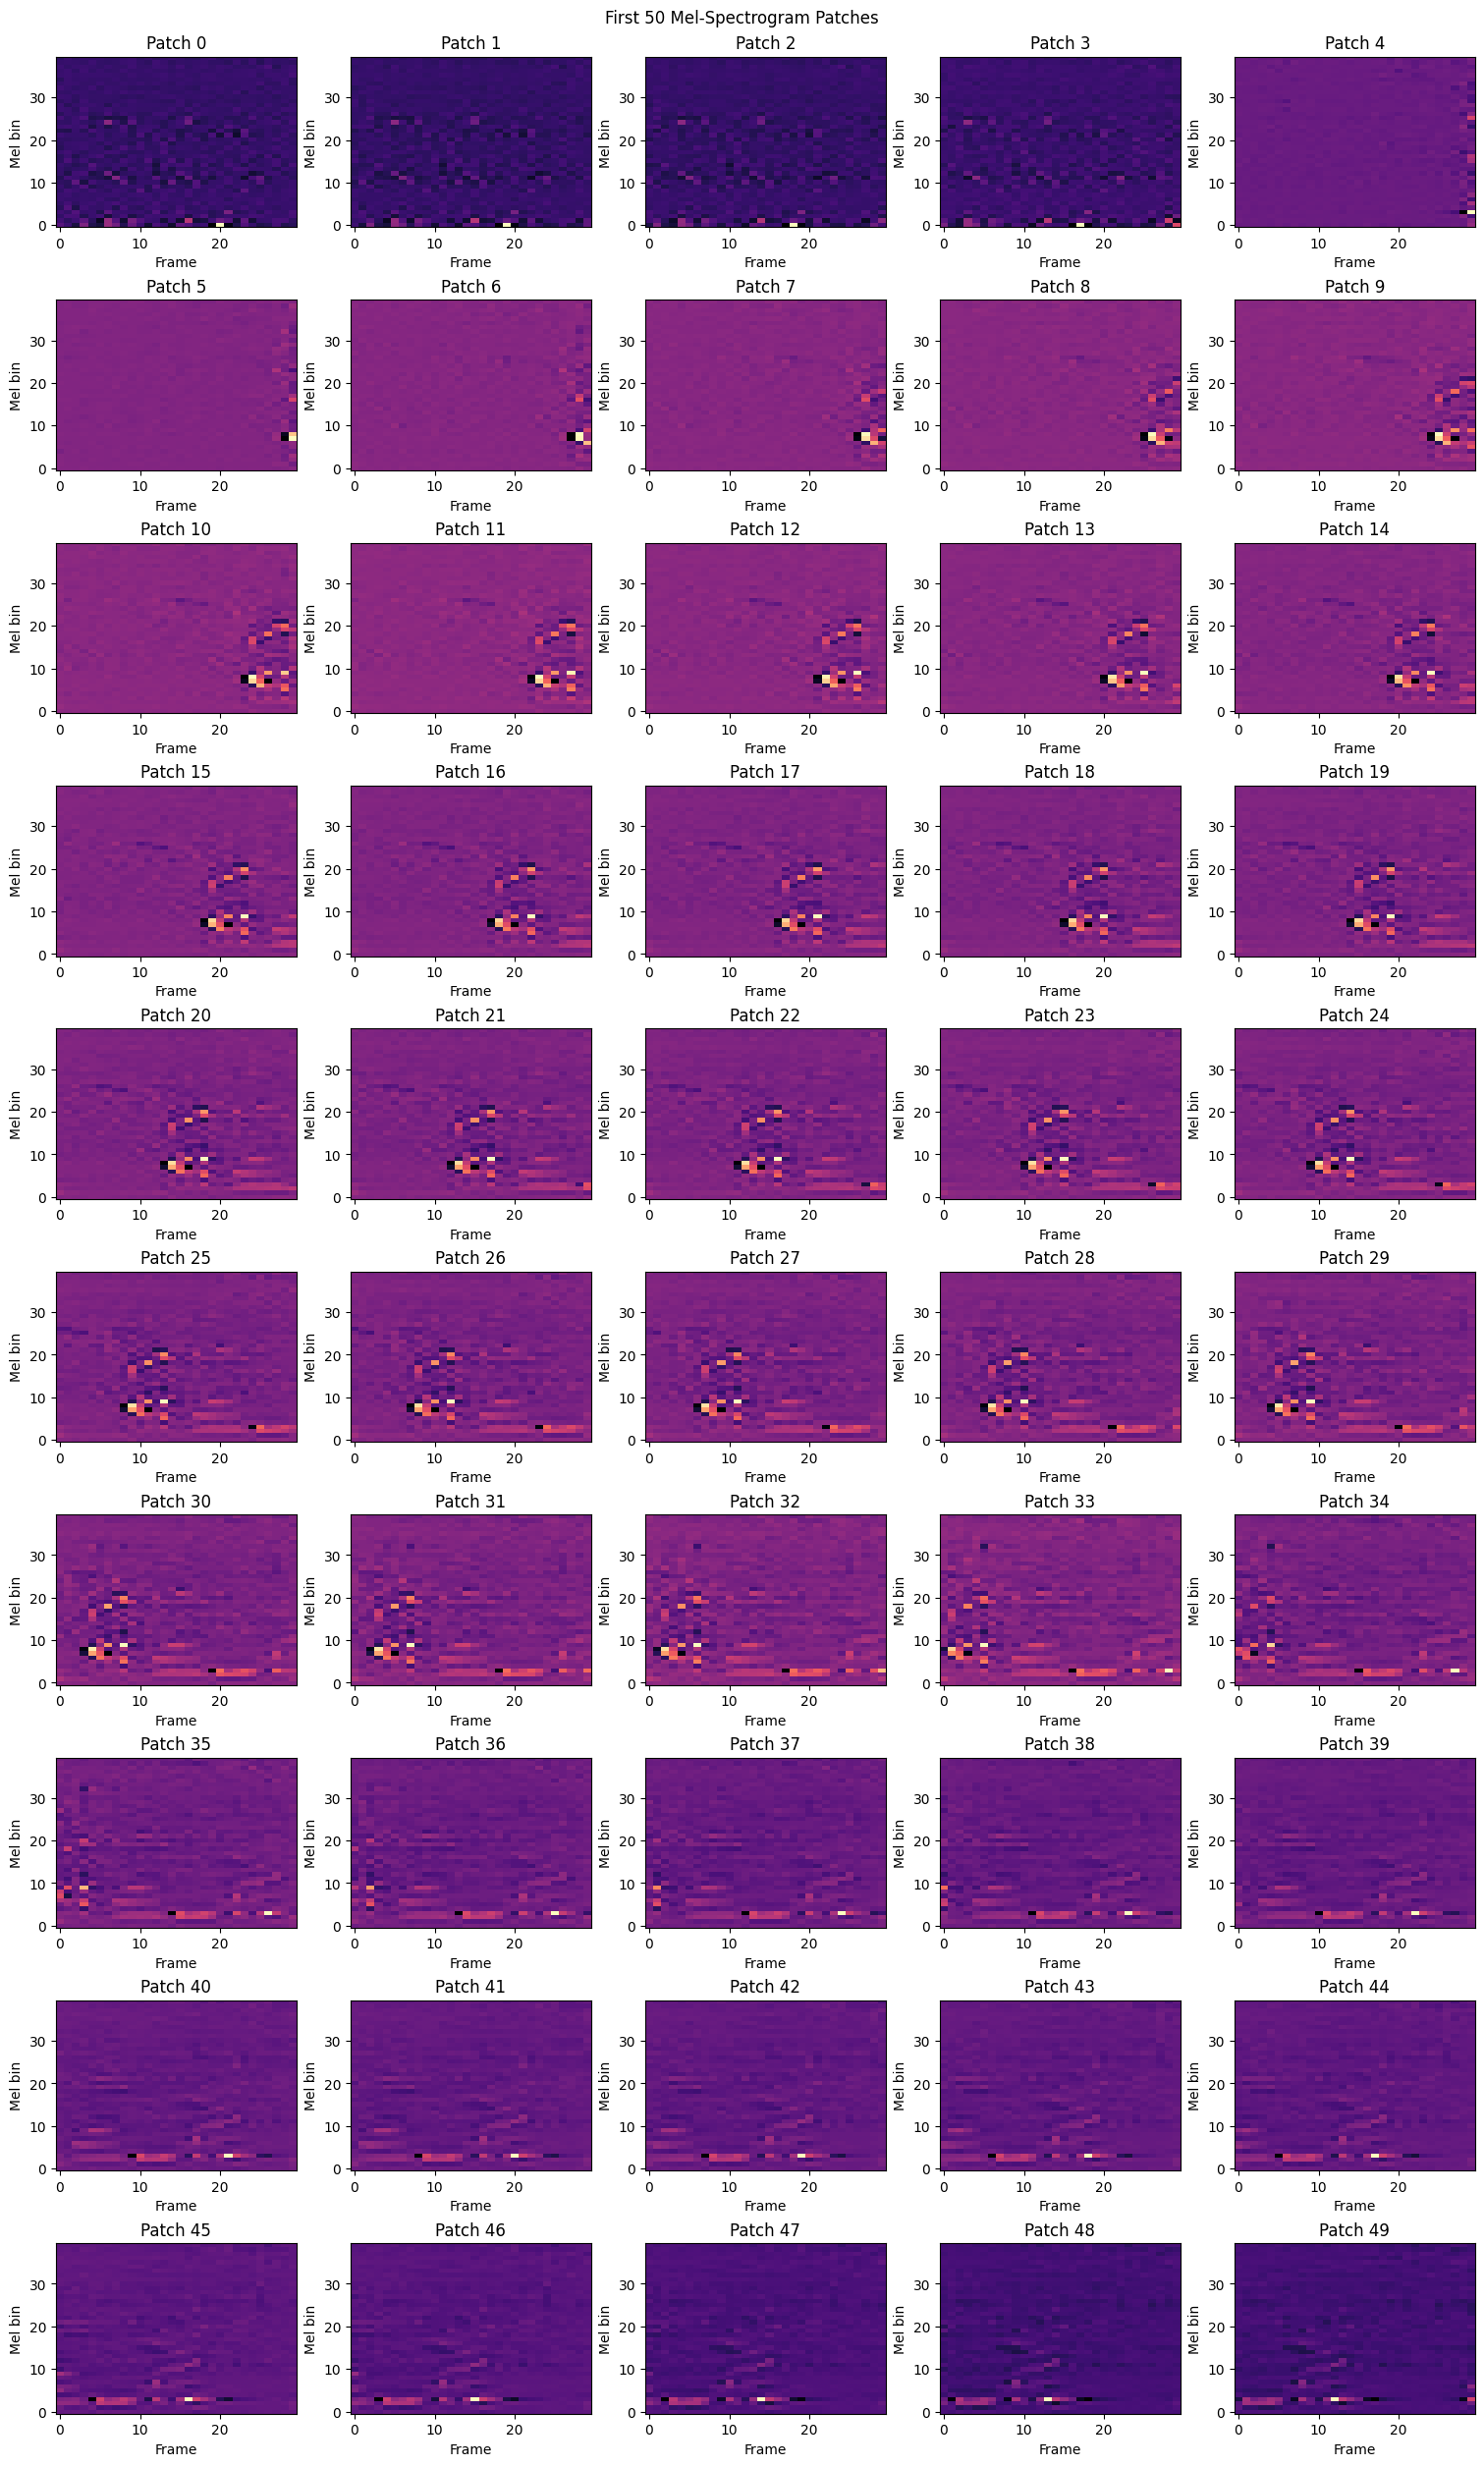

In [234]:
plot_first_10_mel_patches(norm_patches.reshape(norm_patches.shape[0], 40, 30), n_show=50, cols=5)

In [10]:
def apply_kmeans_to_patches(patches, n_clusters=100, sample_size=1000000):
    """
    Apply k-means clustering to 5x5 image patches.
    
    Args:
        patches: torch tensor of shape (N, 5, 5) where N is number of patches
        n_clusters: number of clusters (K)
        normalize_patches: whether to normalize patches to unit norm
        sample_size: if not None, randomly sample this many patches for clustering
    
    Returns:
        kmeans: fitted KMeans object
        cluster_centers: cluster centers reshaped back to (n_clusters, 5, 5)
    """
    if sample_size is not None and sample_size < len(patches):
        # Randomly sample patches
        indices = np.random.choice(len(patches), sample_size, replace=False)
        patches = patches[indices]
    
    # Apply k-means
    kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=43, n_init=10)
    kmeans.fit(patches)
    return kmeans

In [11]:
kmeans=apply_kmeans_to_patches(norm_patches, 2000, sample_size=None)

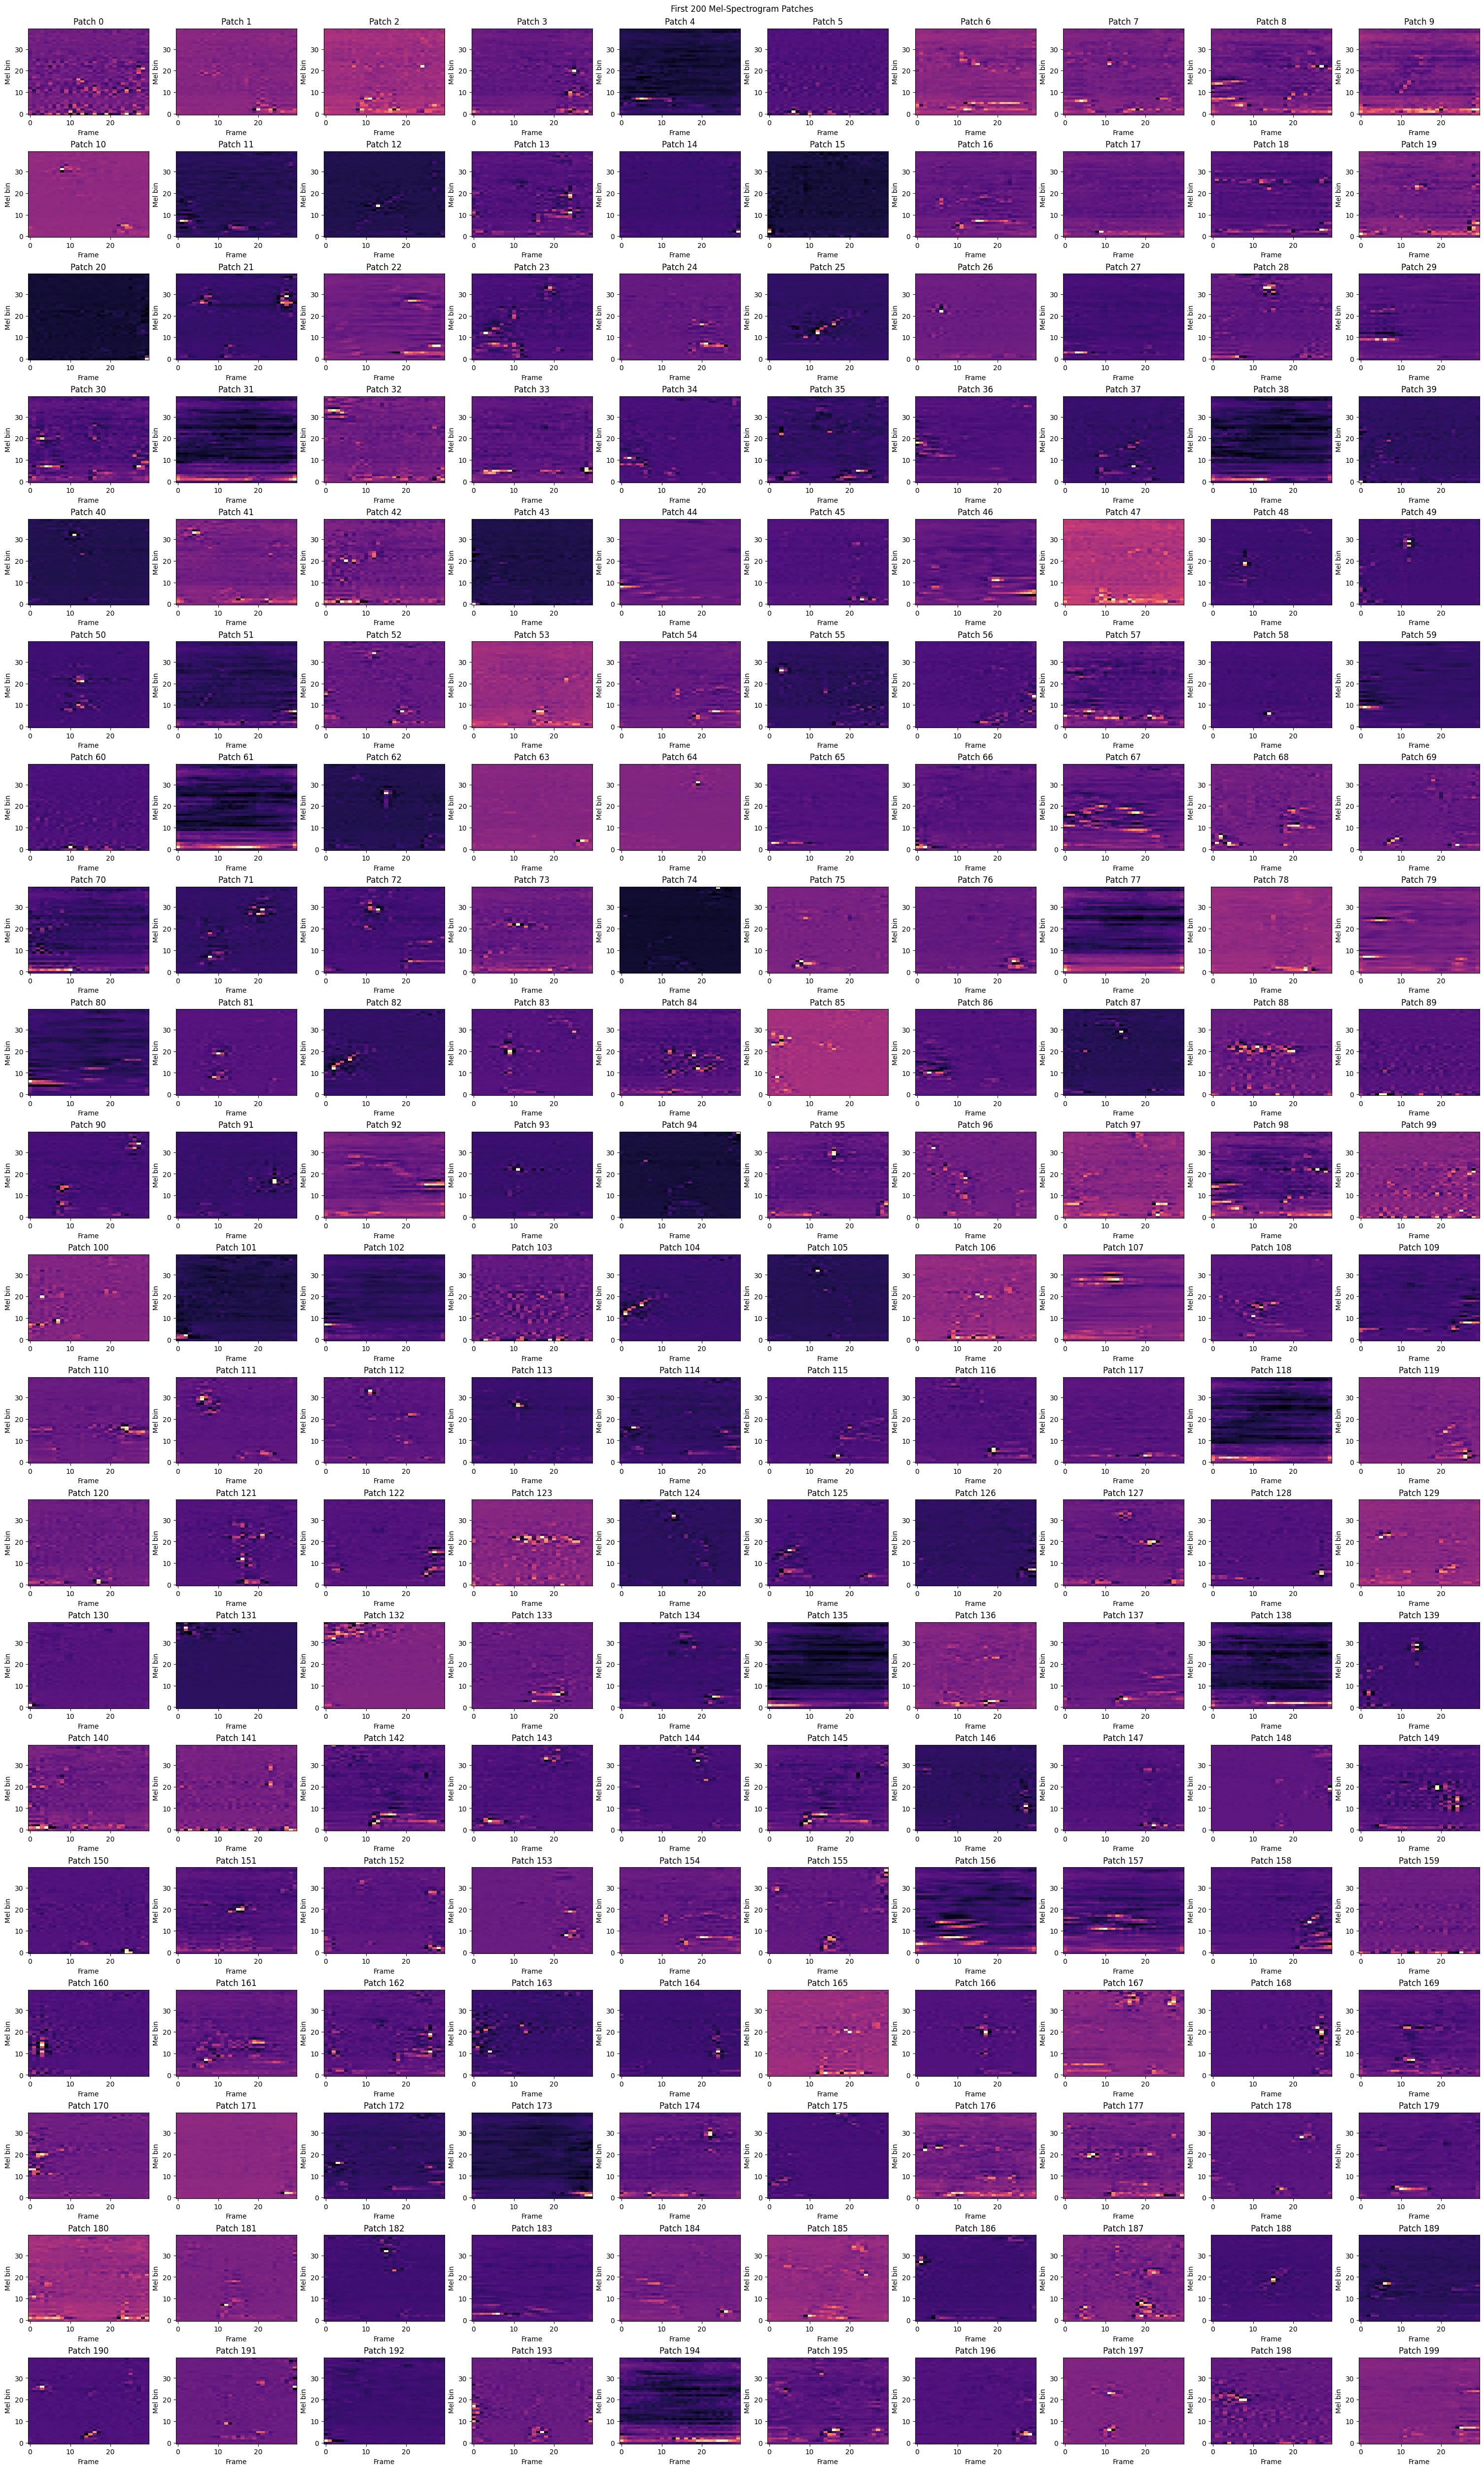

In [12]:
clusters = kmeans.cluster_centers_
clusters = clusters.reshape(clusters.shape[0],40,30)
plot_first_10_mel_patches(clusters, 200, 10)

In [64]:
from scipy.sparse import csr_matrix

labels = kmeans.labels_                  # shape: (n_samples,)
n_samples = labels.shape[0]
n_clusters = kmeans.n_clusters           # or: labels.max() + 1

# Sparse cluster code: shape (n_samples, n_clusters)
A = csr_matrix(
    (np.ones(n_samples, dtype=np.float32), (np.arange(n_samples), labels)),
    shape=(n_samples, n_clusters),
)


In [65]:
A.shape

(7652, 2000)

In [66]:
# M = A@D@D.T@A.T
M = np.zeros((A.shape[1], A.shape[1]))
for (start, end) in utterance_bounds:
    for j in tqdm(range(start, end - 1)):
        if j+1 < A.shape[0]:
            diff = (A[j+1] - A[j]).T
            M += diff@(diff.T)

100%|██████████| 259/259 [00:00<00:00, 532.86it/s]


In [67]:
# transpose A to match SMT formulation
A = A.T

In [70]:
n_samples = A.shape[1]
eps = 1e-6
V = (A @ A.T) / n_samples
V += eps * np.eye(V.shape[0])

In [71]:
from scipy.linalg import eigh

eigvals, eigvecs = eigh(M, V)

In [72]:
d = 32  # embedding dimension
P = eigvecs[:, 1:d+1].T

## Sparse coding using FISTA


In [ ]:
def quadraticBasisUpdate(basis, Res, ahat, lowestActivation, HessianDiag, stepSize = 0.001,constraint = 'L2', Noneg = False):
    """
    This matrix update the basis function based on the Hessian matrix of the activation.
    It's very similar to Newton method. But since the Hessian matrix of the activation function is often ill-conditioned, we takes the pseudo inverse.

    Note: currently, we can just use the inverse of the activation energy.
    A better idea for this method should be caculating the local Lipschitz constant for each of the basis.
    The stepSize should be smaller than 1.0 * min(activation) to be stable.
    """
    dBasis = stepSize*torch.mm(Res, ahat.t())/ahat.size(1)
    dBasis = dBasis.div_(HessianDiag+lowestActivation)
    basis = basis.add_(dBasis)
    if Noneg:
        basis = basis.clamp(min = 0.)
    if constraint == 'L2':
        basis = basis.div_(basis.norm(2,0))
    return basis
    
def FISTA(I,basis,lambd,num_iter,eta=None, useMAGMA=True):
    # This is a positive-only PyTorch-Ver FISTA solver
    dtype = basis.type()
    batch_size=I.size(1)
    M = basis.size(1)
    if eta is None:
        if useMAGMA:
            L = torch.max(torch.symeig(torch.mm(basis,basis.t()),eigenvectors=False)[0])
            eta = 1./L
        else:
            eta = 1./cp.linalg.eigvalsh(cp.asarray(torch.mm(basis,basis.t()).cpu().numpy())).max().get().reshape(1)
            eta = torch.from_numpy(eta.astype('float32')).cuda()

    tk_n = 1.
    tk = 1.
    Res = torch.cuda.FloatTensor(I.size()).fill_(0)
    ahat = torch.cuda.FloatTensor(M,batch_size).fill_(0)
    ahat_y = torch.cuda.FloatTensor(M,batch_size).fill_(0)

    for t in range(num_iter):
        tk = tk_n
        tk_n = (1+np.sqrt(1+4*tk**2))/2
        ahat_pre = ahat
        Res = I - torch.mm(basis,ahat_y)
        ahat_y = ahat_y.add(eta * basis.t().mm(Res))
        ahat = ahat_y.sub(eta * lambd).clamp(min = 0.)
        ahat_y = ahat.add(ahat.sub(ahat_pre).mul((tk-1)/(tk_n)))
    Res = I - torch.mm(basis,ahat)
    return ahat, Res